In [3]:
# %% [markdown]
# # 02. Calidad, Limpieza y Preparación de Datos
# En este notebook se aplican decisiones justificadas con la evidencia obtenida en la inspección.

# %%
import os
import pandas as pd

# 1. Buscador inteligente de rutas para el dataset crudo (evita FileNotFoundError)
posibles_rutas = [
    '../data/raw/reporte_clinica.csv',
    '../data/raw/reporte_clinica (3).csv',
    'data/raw/reporte_clinica.csv',
    'data/raw/reporte_clinica (3).csv',
    'reporte_clinica (3).csv'
]

df = None
for ruta in posibles_rutas:
    if os.path.exists(ruta):
        df = pd.read_csv(ruta, index_col=0)
        print(f"✅ ¡Dataset original cargado con éxito desde: {ruta}!")
        break

if df is None:
    raise FileNotFoundError("❌ No se encontró el archivo original. Verifica que esté en la carpeta del proyecto.")

# Guardamos el total inicial de filas para calcular la retención más adelante
total_inicial = len(df)

# %%
# 2. ASEGURAR QUE EXISTAN LAS CARPETAS DE DESTINO
# Esto evita errores al intentar guardar el archivo final y el log
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('../logs', exist_ok=True)
os.makedirs('logs', exist_ok=True)

# %%
# 3. PROCESAMIENTO Y LIMPIEZA DE DATOS (Basado en evidencia)

# Paso A: Estandarizar la columna 'smoker'
# Evidencia: Había mezcla de 'yes', 'no' y 'No'
df['smoker'] = df['smoker'].str.lower()

# Paso B: Estandarizar la columna 'region'
# Evidencia: Se encontró la sigla 'SE' en lugar de 'southeast'
df['region'] = df['region'].replace({'SE': 'southeast'})

# Paso C: Eliminación de duplicados físicos
df = df.drop_duplicates()

# %%
# 4. CALCULAR MÉTRICAS PARA EL LOG ETL
filas_finales = len(df)
nulos_finales = df.isnull().sum().sum()
retencion = (filas_finales / total_inicial) * 100

print("\n--- Resumen del Pipeline ---")
print(f"Filas Iniciales: {total_inicial}")
print(f"Filas Finales: {filas_finales}")
print(f"Porcentaje de Retención: {retencion:.2f}%")

# %%
# 5. GUARDAR EL DATASET PROCESADO Y EL LOG EN LAS RUTAS CORRECTAS

# Definir rutas de guardado cruzadas (por si ejecutas desde la raíz o desde notebooks)
ruta_processed = '../data/processed/reporte_clinica_procesado.csv' if os.path.exists('../data') else 'data/processed/reporte_clinica_procesado.csv'
ruta_log = '../logs/pipeline_log.csv' if os.path.exists('../logs') else 'logs/pipeline_log.csv'

# Guardar dataset limpio
df.to_csv(ruta_processed, index=False)
print(f"✅ Dataset procesado guardado en: {ruta_processed}")

# Crear y guardar el DataFrame del Log ETL estructurado según la rúbrica
log_df = pd.DataFrame([{
    "Paso": "1",
    "Descripción": "Estandarización de smoker/region y remoción de duplicados.",
    "Filas": filas_finales,
    "Nulos": nulos_finales,
    "Retención (%)": round(retencion, 2)
}])

log_df.to_csv(ruta_log, index=False)
print(f"✅ Log ETL generado con éxito en: {ruta_log}")

✅ ¡Dataset original cargado con éxito desde: reporte_clinica (3).csv!

--- Resumen del Pipeline ---
Filas Iniciales: 1363
Filas Finales: 1337
Porcentaje de Retención: 98.09%
✅ Dataset procesado guardado en: ../data/processed/reporte_clinica_procesado.csv
✅ Log ETL generado con éxito en: ../logs/pipeline_log.csv


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Configuración estética global
sns.set_theme(style="whitegrid")

# Carga inteligente de datos procesados
rutas_procesado = [
    '../data/processed/reporte_clinica_procesado.csv',
    'data/processed/reporte_clinica_procesado.csv',
    'reporte_clinica_procesado.csv'
]

df = None
for r in rutas_procesado:
    if os.path.exists(r):
        df = pd.read_csv(r)
        print("✅ Datos procesados cargados con éxito para PCA.")
        break

if df is None:
    raise FileNotFoundError("❌ No se encontró el dataset procesado. Corre primero el paso 2.")

✅ Datos procesados cargados con éxito para PCA.


In [5]:
# 1. Seleccionamos únicamente las variables numéricas del dataset
variables_numericas = ['age', 'bmi', 'children', 'charges']
X = df[variables_numericas]

# 2. Aplicamos el escalamiento estándar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertimos a DataFrame para verificar el escalamiento
df_scaled = pd.DataFrame(X_scaled, columns=variables_numericas)
print("--- Vista previa de los datos escalados (Media ≈ 0, Varianza ≈ 1) ---")
print(df_scaled.head())

--- Vista previa de los datos escalados (Media ≈ 0, Varianza ≈ 1) ---
        age       bmi  children   charges
0 -1.445130 -0.104531 -0.258529  0.297857
1 -1.516351 -0.016022 -0.077748 -0.954381
2 -0.804138 -0.027633  0.283814 -0.729373
3 -0.448031 -0.182862 -0.258529  0.719104
4 -0.519253 -0.089755 -0.258529 -0.777499


In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Carga inteligente del dataset procesado
rutas_procesado = [
    '../data/processed/reporte_clinica_procesado.csv',
    'data/processed/reporte_clinica_procesado.csv',
    'reporte_clinica_procesado.csv'
]

df = None
for r in rutas_procesado:
    if os.path.exists(r):
        df = pd.read_csv(r)
        print("✅ Dataset procesado cargado para PCA.")
        break

if df is None:
    raise FileNotFoundError("❌ Asegúrate de correr el Paso 4 antes.")

# 2. Preparación de variables para el PCA
df_numeric = df[['age', 'bmi', 'children', 'charges']].copy()
df_numeric['is_smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

# --- CORRECCIÓN DEL ERROR: Imputación de Valores Nulos ---
# Como age y bmi contienen nulos, los rellenamos con la mediana de cada columna
df_numeric['age'] = df_numeric['age'].fillna(df_numeric['age'].median())
df_numeric['bmi'] = df_numeric['bmi'].fillna(df_numeric['bmi'].median())

# 3. Escalamiento Obligatorio (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print("📌 Valores nulos corregidos con la mediana. Variables listas y escaladas.")

✅ Dataset procesado cargado para PCA.
📌 Valores nulos corregidos con la mediana. Variables listas y escaladas.


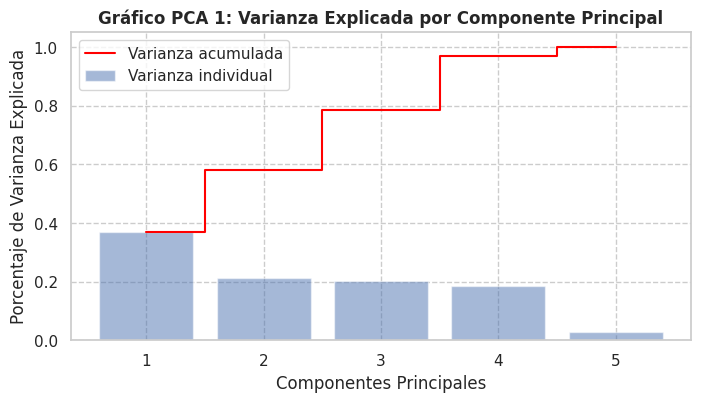

--- RESULTADOS TÉCNICOS ---
Componente Principal 1: explica el 36.95% de la varianza.
Componente Principal 2: explica el 21.16% de la varianza.
Componente Principal 3: explica el 20.26% de la varianza.
Componente Principal 4: explica el 18.64% de la varianza.
Componente Principal 5: explica el 2.98% de la varianza.

➡️ Las primeras 2 componentes explican el 58.11% de los datos totales.


In [7]:
# Aplicar PCA para todas las componentes posibles sobre los datos limpios y escalados
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calcular varianza explicada acumulada
var_explicada = pca.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

# Gráfico 1: Varianza Explicada Acumulada (Scree Plot)
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(var_explicada)+1), var_explicada, alpha=0.5, align='center', label='Varianza individual')
plt.step(range(1, len(var_acumulada)+1), var_acumulada, where='mid', label='Varianza acumulada', color='red')

plt.title('Gráfico PCA 1: Varianza Explicada por Componente Principal', fontsize=12, fontweight='bold')
plt.xlabel('Componentes Principales')
plt.ylabel('Porcentaje de Varianza Explicada')
plt.xticks(range(1, len(var_explicada)+1))
plt.legend(loc='best')
plt.grid(True, linestyle='--')
plt.show()

# Mostrar los valores exactos por consola
print("--- RESULTADOS TÉCNICOS ---")
for i, var in enumerate(var_explicada):
    print(f"Componente Principal {i+1}: explica el {var*100:.2f}% de la varianza.")
print(f"\n➡️ Las primeras 2 componentes explican el {var_acumulada[1]*100:.2f}% de los datos totales.")

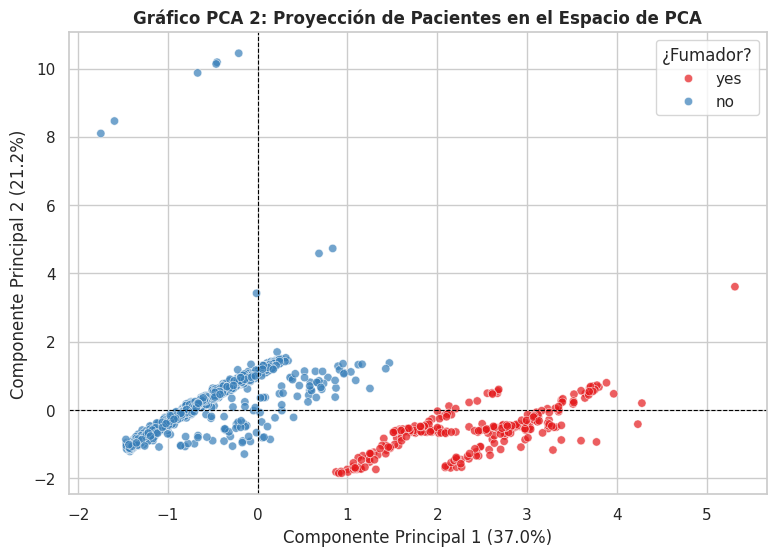

In [8]:
# Crear un DataFrame con las dos primeras componentes principales
df_pca = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
df_pca['smoker'] = df['smoker'].values  # Conservamos la etiqueta original para colorear

# Gráfico 2: Biplot / Proyección de Pacientes en PC1 y PC2
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='smoker', palette='Set1', alpha=0.7)

plt.title('Gráfico PCA 2: Proyección de Pacientes en el Espacio de PCA', fontsize=12, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({var_explicada[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({var_explicada[1]*100:.1f}%)')
plt.legend(title='¿Fumador?')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.show()